# iEFC demo

In [1]:

import numpy as np
import astropy.units as u
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from importlib import reload
from astropy.io import fits
import copy
import time
import tomlkit

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle
from matplotlib.gridspec import GridSpec

import lina_cpp as lina
from lina_cpp.math_module import xp, xcipy, ensure_np_array
from lina_cpp import control_models as cm
from lina_cpp import utils, wfe, dm, iefc

if not lina.gpu_available():
    raise RuntimeError("lina_cpp was built without CUDA support.")

lina.set_backend("gpu")

print(f"lina_cpp_gpu_available={lina.gpu_available()}")
print(f"xp_module={xp.__name__}")
print(f"lina_cpp_device={lina.get_device()}")
print(f"control_model_class={cm.MODEL.__name__}")

if cm.MODEL.__name__ != "MODEL_CPP":
    raise RuntimeError("Notebook requires C++ MODEL_CPP backend.")


def report_cpp_backend(label, model=None):
    print(f"[{label}] xp={xp.__name__}, lina_cpp_device={lina.get_device()}")
    if model is not None and hasattr(model, "_cpp_model"):
        model._sync_cpp_device()
        print(f"[{label}] control_model_device={model._cpp_model.device()}")


def report_array_backend(name, arr):
    if hasattr(arr, "__cuda_array_interface__"):
        print(f"{name}: GPU array, shape={arr.shape}, dtype={arr.dtype}")
    else:
        print(f"{name}: CPU ({type(arr).__name__}), shape={getattr(arr, 'shape', None)}")


/home/adams/.local/lib/python3.10/site-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


lina_cpp_gpu_available=True
xp_module=cupy
lina_cpp_device=gpu
control_model_class=MODEL_CPP


# Setup the models for the LLOWFSC images and the coronagraph images used to evaluate contrast performance and estimate residuals from LLOWSFC.

Oversampling > 2x suggested for reliable results in Fresnel propagation.
Oversampling > 2x suggested for reliable results in Fresnel propagation.
Oversampling > 2x suggested for reliable results in Fresnel propagation.


[after MODEL init] xp=cupy, lina_cpp_device=gpu
[after MODEL init] control_model_device=gpu
generate_wfe_elapsed_s=0.649
(514, 514) (514, 514)
prefpm_wfe_amp: GPU array, shape=(514, 514), dtype=float64
prefpm_wfe_opd: GPU array, shape=(514, 514), dtype=float64


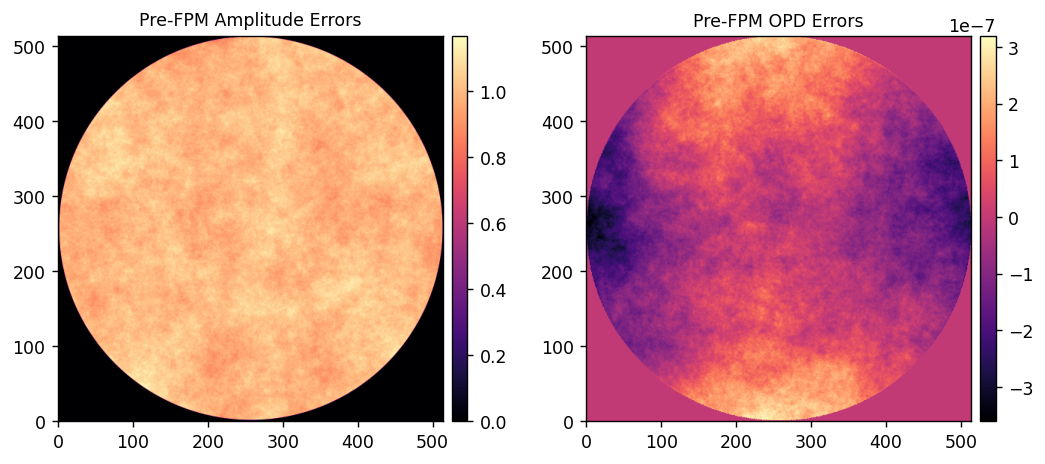

flat_dm_optimization_elapsed_s=0.114
flat_command: GPU array, shape=(34, 34), dtype=float64
flat_command_opd: GPU array, shape=(514, 514), dtype=float64


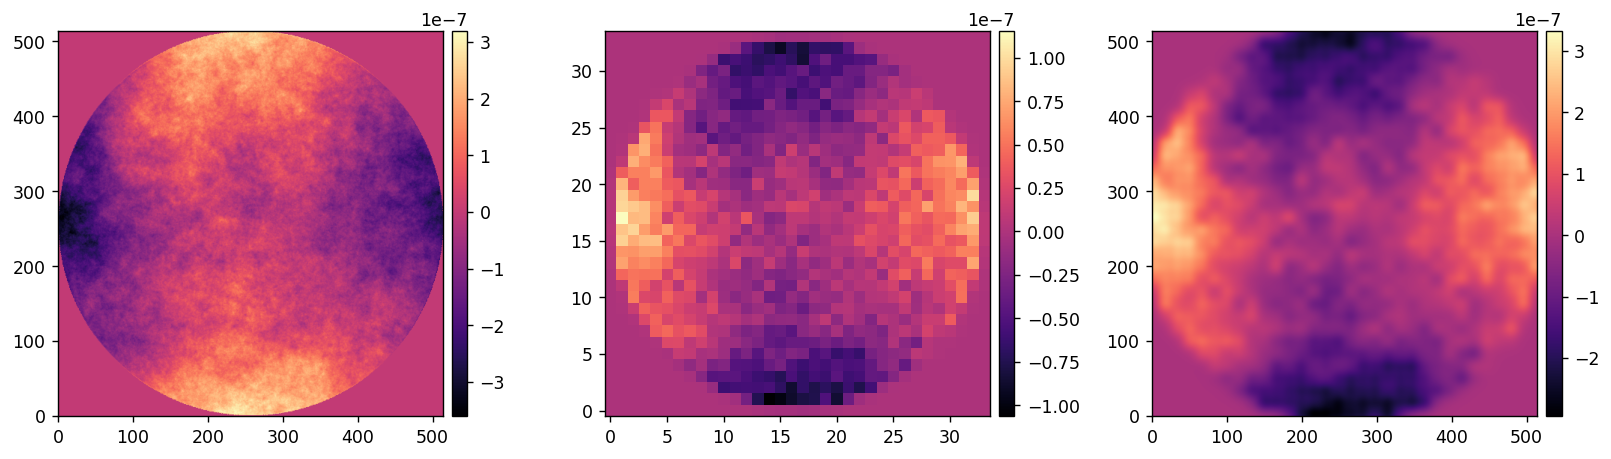

In [2]:
reload(cm)
reload(utils)
reload(wfe)
reload(dm)
reload(iefc)

model_params = {
    'wavelength_c':630e-9,
    'npix':512,
    'N_vortex_lres':2048,
    'vortex_hres_sampling':0.025,
    'vortex_win_diam':30,
    'vortex_dot_mask_diam_lamDc':0.65,
    'ncamsci':256,
    'camsci_pxscl_lamDc':0.2,
    'Nact':34,
    'dm_beam_diam':9.3e-3,
    'lyot_pupil_diam':4.2e-3,
    'lyot_stop_diam':3.7e-3,
    'act_spacing':300e-6,
}

if not getattr(cm, '_HAS_CPP_CONTROL_MODEL', False):
    raise RuntimeError('lina_cpp._core missing ControlModelCpp.')

C = cm.MODEL(
    **model_params,
)
if not hasattr(C, '_cpp_model'):
    raise RuntimeError('MODEL instance is not backed by ControlModelCpp.')
report_cpp_backend('after MODEL init', C)

prefpm_slope = 2.5
prefpm_opd_rms = 40*u.nm
prefpm_amp_rms = 0.05
dm_astig_rms = 10e-8

t_wfe_start = time.perf_counter()
prefpm_wfe_amp, prefpm_wfe_opd = wfe.generate_wfe(
    npix=C.npix,
    oversample=C.def_oversample,
    wavelength=C.wavelength_c,
    opd_index=prefpm_slope, amp_index=prefpm_slope,
    opd_rms=prefpm_opd_rms,
    amp_rms=prefpm_amp_rms,
    remove_amp_modes=12,
    remove_opd_modes=3,
    opd_seed=12,
    amp_seed=123,
)
print(f'generate_wfe_elapsed_s={time.perf_counter() - t_wfe_start:.3f}')

print(prefpm_wfe_amp.shape, prefpm_wfe_opd.shape)
report_array_backend('prefpm_wfe_amp', prefpm_wfe_amp)
report_array_backend('prefpm_wfe_opd', prefpm_wfe_opd)
dm_astig = - dm_astig_rms * wfe.create_zernike_modes(C.APERTURE, nmodes=1, remove_modes=5)[0]
prefpm_wfe_opd += dm_astig
utils.imshow(
    [prefpm_wfe_amp, prefpm_wfe_opd],
    titles=['Pre-FPM Amplitude Errors', 'Pre-FPM OPD Errors'],
)

# Flat-DM solve. The flat-DM fit is ill-conditioned at the aperture-edge
# actuators (weakly illuminated influence functions), so the solution there is
# only weakly constrained. We use SciPy's L-BFGS-B as the (tiny, fast) outer
# optimizer -- matching the pure-Python reference to floating-point precision,
# including the edge actuators -- while the objective/gradient cm.dm_val_and_grad
# and the optical forward run through the C++/CUDA backend.
#
# A fully native solver is also available: cm.solve_flat_command(C, opd)
# (conjugate gradient in C++). It returns a valid minimizer but lands on a
# different point in the weakly-constrained edge subspace, so it does not match
# the reference at the rim actuators.
from scipy.optimize import minimize

t_flat_start = time.perf_counter()
res = minimize(
    cm.dm_val_and_grad,
    jac=True,
    x0=np.zeros(C.Nacts),
    args=(prefpm_wfe_opd, C),
    method='L-BFGS-B',
    tol=1e-4,
    options={'disp': True},
)
print(f'flat_dm_optimization_elapsed_s={time.perf_counter() - t_flat_start:.3f}')

flat_command = xp.zeros((C.Nact, C.Nact))
flat_command[C.dm_mask] = xp.array(res.x)

mft_command = C.Mx_dm @ flat_command @ C.My_dm
fourier_surf = C.inf_fun_fft * mft_command
flat_command_surf = xp.fft.fftshift(xp.fft.ifft2(xp.fft.ifftshift(fourier_surf,))).real
flat_command_opd = 2 * utils.pad_or_crop(flat_command_surf, C.Ndef)
report_array_backend('flat_command', flat_command)
report_array_backend('flat_command_opd', flat_command_opd)

utils.imshow([prefpm_wfe_opd, flat_command, flat_command_opd])

In [3]:

print(flat_command.max())
print(flat_command_opd.max())

1.151722677745167e-07
3.3216215292038325e-07


ref_psf: GPU array, shape=(256, 256), dtype=float64
coro_im: GPU array, shape=(256, 256), dtype=float64


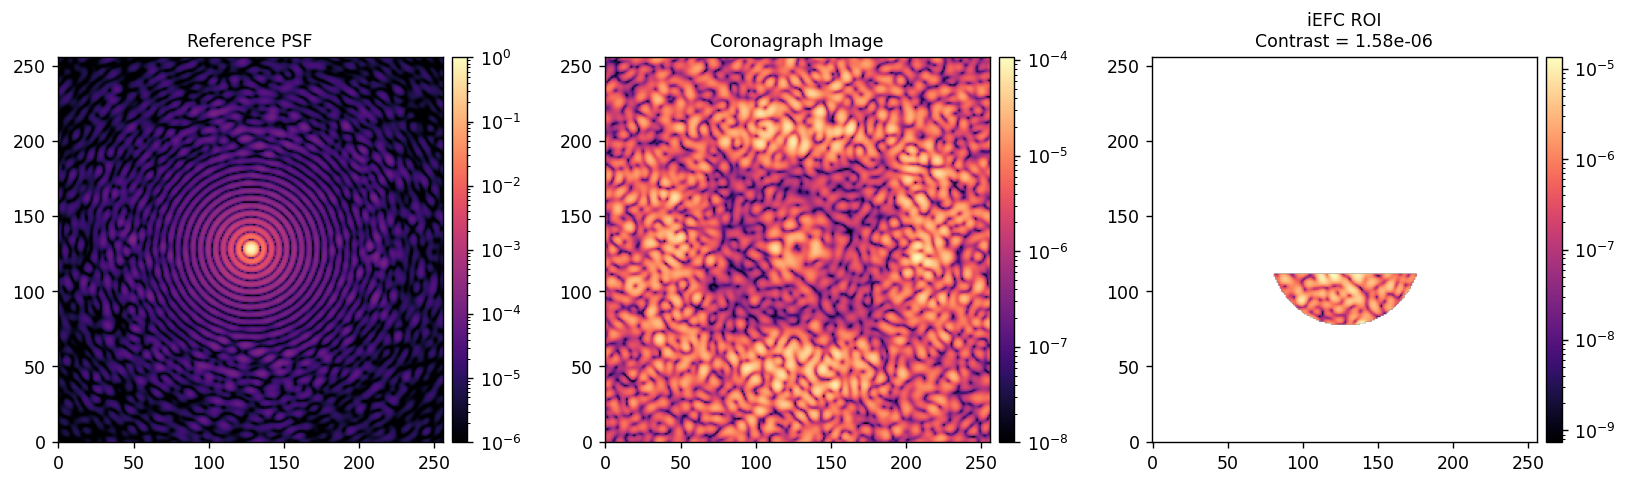

In [5]:
C.PREFPM_AMP = prefpm_wfe_amp
C.PREFPM_OPD = prefpm_wfe_opd
C.dm_commands[0] = flat_command

C.Imax_ref = 1
C.use_vortex = 0
ref_psf = C.snap()
C.Imax_ref = xp.max(ref_psf)

C.use_vortex = 1
coro_im = C.snap()
report_array_backend('ref_psf', ref_psf)
report_array_backend('coro_im', coro_im)

iwa, owa = (3, 10)
wfs_mask = utils.create_annular_focal_plane_mask(
    C.ncamsci, 
    C.camsci_pxscl_lamDc, 
    iwa, 
    owa, 
    edge=iwa, 
    rotation=90, 
    centering='odd',
    # return_np=1,
)
contrast = utils.mean(coro_im, wfs_mask)

utils.imshow(
    [ref_psf/C.Imax_ref, coro_im, coro_im * wfs_mask],
    norms=[LogNorm(1e-6), LogNorm(1e-8), LogNorm()],
    titles=['Reference PSF', 'Coronagraph Image', f'iEFC ROI\nContrast = {contrast:.2e}']
    # cmaps=['magma'],
)

# Setup the control model with the same model parameters used for the instrument model (so there are no model errors here).

Oversampling > 2x suggested for reliable results in Fresnel propagation.
Oversampling > 2x suggested for reliable results in Fresnel propagation.


[after secondary MODEL init] xp=cupy, lina_cpp_device=gpu
[after secondary MODEL init] control_model_device=gpu


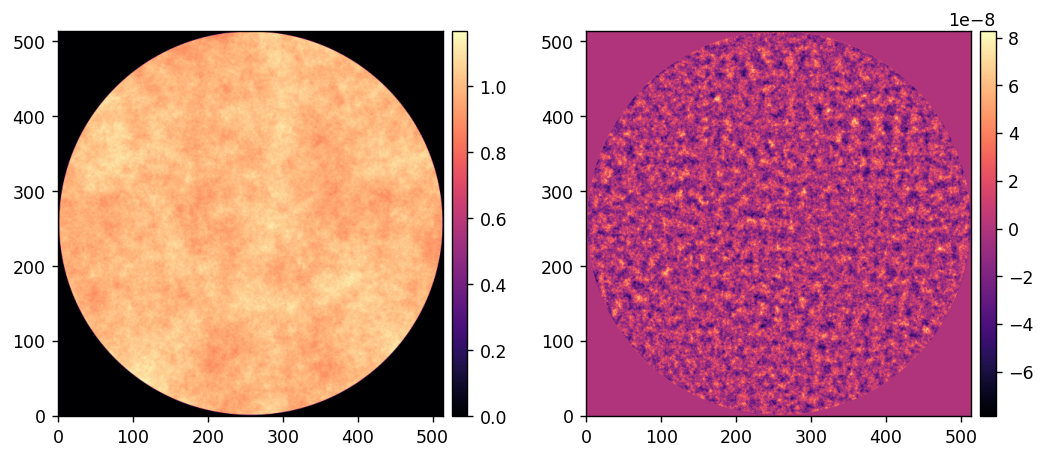

model_psf: GPU array, shape=(256, 256), dtype=float64
model_coro_im: GPU array, shape=(256, 256), dtype=float64


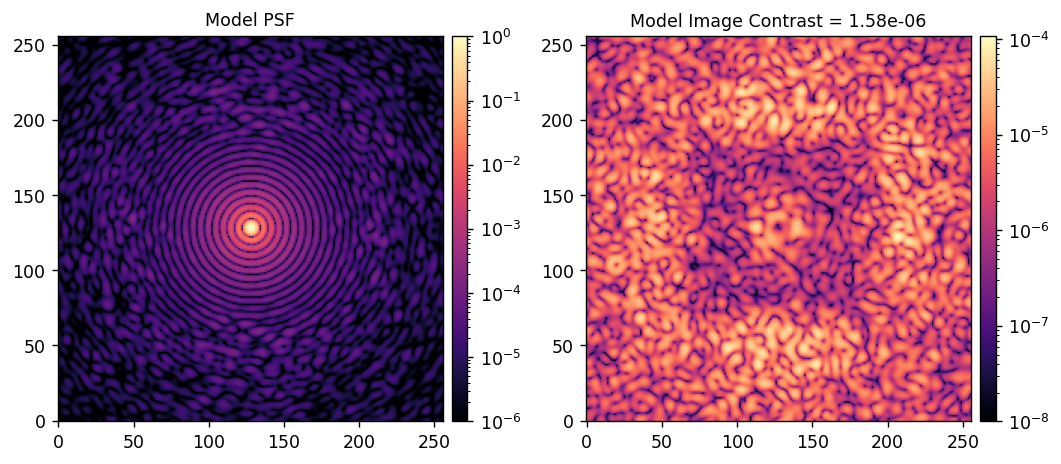

In [6]:
M = cm.MODEL(
    **model_params,
)
if not hasattr(M, '_cpp_model'):
    raise RuntimeError('Second model instance is not backed by ControlModelCpp.')
report_cpp_backend('after secondary MODEL init', M)

M.PREFPM_AMP = C.PREFPM_AMP
M.PREFPM_OPD = M.APERTURE * (C.PREFPM_OPD + flat_command_opd)

utils.imshow(
    [M.PREFPM_AMP, M.PREFPM_OPD]
)

M.Imax_ref = 1
M.use_vortex = 0
model_psf = M.snap()

M.Imax_ref = model_psf.max()
M.use_vortex = 1
model_coro_im = M.snap()
report_array_backend('model_psf', model_psf)
report_array_backend('model_coro_im', model_coro_im)
contrast = utils.mean(model_coro_im, wfs_mask)

utils.imshow(
    [model_psf/M.Imax_ref, model_coro_im],
    norms=[LogNorm(1e-6), LogNorm(1e-8)],
    titles=['Model PSF', f'Model Image Contrast = {contrast:.2e}'],
)

# Setup the functions needed for iEFC

In [7]:
dm_mask = dm.create_mask(Nact=M.Nact)

def take_im_fun(C):
    coro_im = C.snap()
    return coro_im

def set_dm_fun(command, C, channel=1):
    C.dm_commands[channel] = command
    return

def get_dm_fun(C, channel=1):
    return C.dm_commands[channel]

take_im_params = {'C':C}
set_dm_params = {'C':C, 'channel':3}
get_dm_params = {'C':C, 'channel':3}

# Make the probes and calibration modes. 

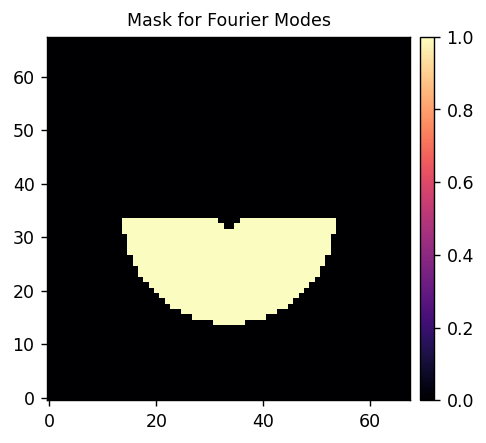

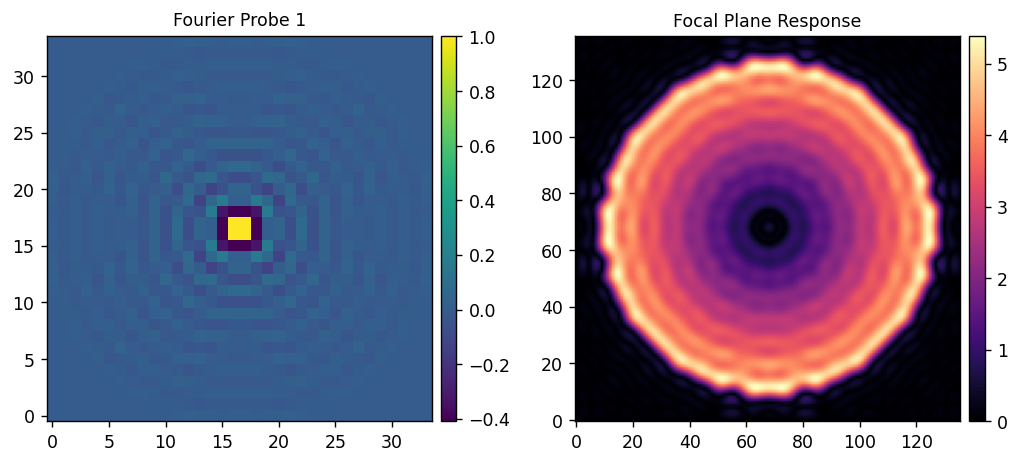

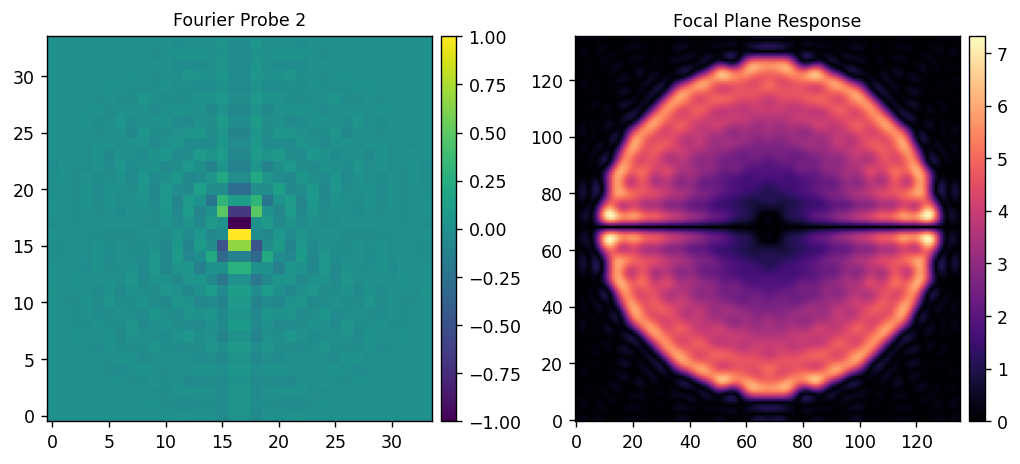

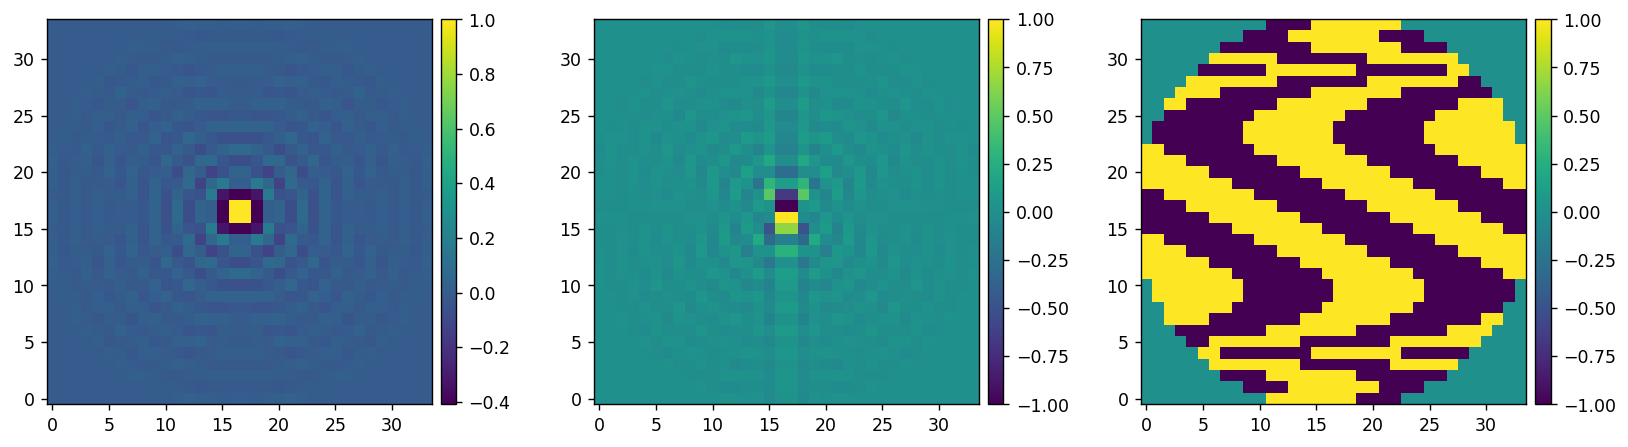

In [8]:
reload(utils)
reload(dm)
probe_modes = dm.create_fourier_probes(
    dm_mask, 
    M.ncamsci, 
    M.camsci_pxscl_lamDc, 
    2,
    14, 
    rotation=90,
    use_weighting=True,
    nprobes=2,
    plot=1,
    # return_np=1, 
)

calib_modes = dm.create_hadamard_modes(
    dm_mask, 
    # return_np=1,
)

utils.imshow([probe_modes[0], probe_modes[1], calib_modes[8]], cmaps=3*['viridis'])

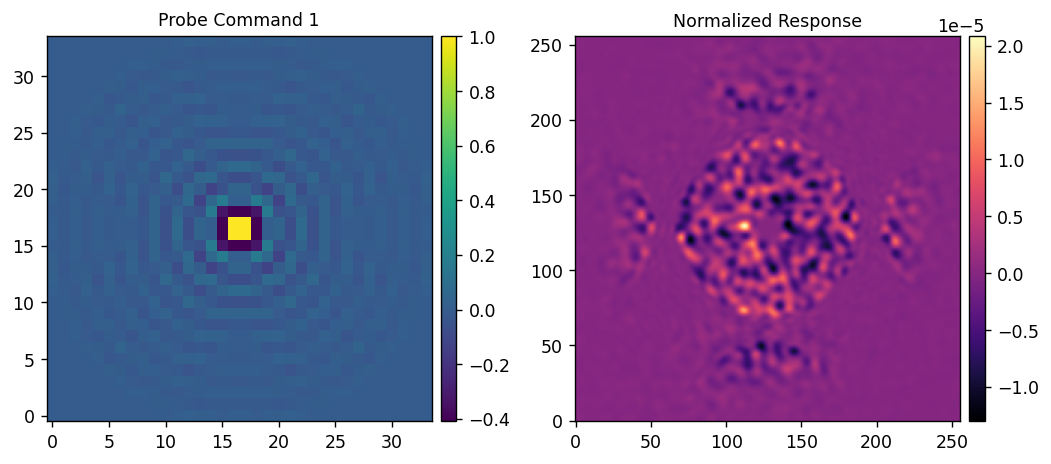

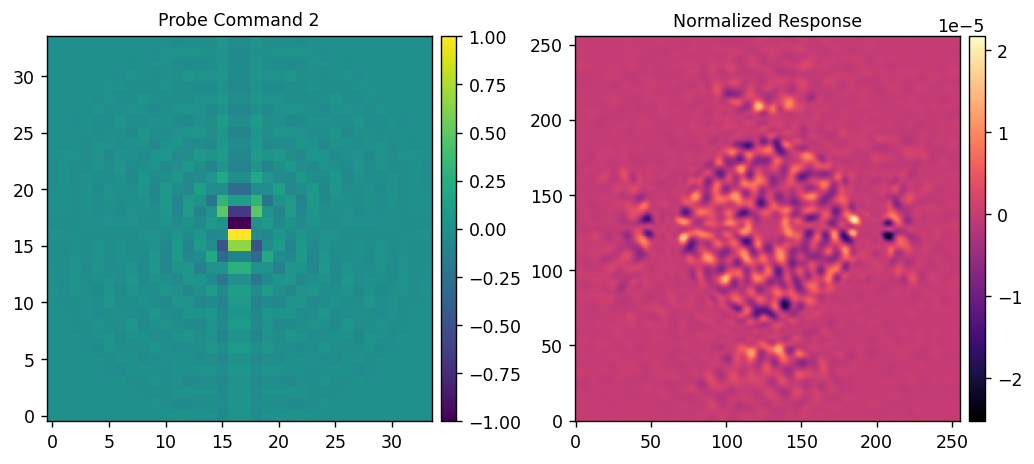

In [9]:
reload(iefc)

diff_ims = iefc.measure_probe_response(
    take_im_fun,
    take_im_params,
    set_dm_fun,
    set_dm_params,
    probe_modes,
    10e-9,
    plot=1,
)

[before calibrate] xp=cupy, lina_cpp_device=gpu
[before calibrate] control_model_device=gpu
Calibrating iEFC... (native C++)
	Calibrated mode 1024/1024 in 13.838s


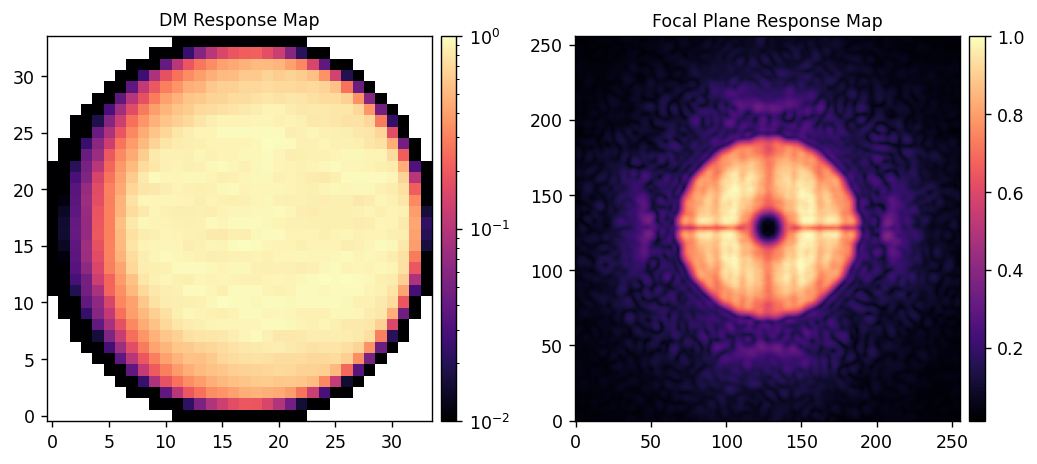

Calibration complete.
iefc_calibrate_elapsed_s=15.254
response_matrix_shape=(4788, 1024)
response_cube_shape=(1024, 2, 256, 256)
response_matrix: GPU array, shape=(4788, 1024), dtype=float64
response_cube: GPU array, shape=(1024, 2, 256, 256), dtype=float64


In [10]:
reload(iefc)

if not getattr(iefc, '_HAS_CPP_IEFC_CALIBRATE', False):
    raise RuntimeError('lina_cpp._core missing native iEFC calibrate endpoint.')
report_cpp_backend('before calibrate', C)

calib_probe_amp = 5e-9
calib_mode_amp = 2e-9

t_calib_start = time.perf_counter()
response_matrix, response_cube = iefc.calibrate(
    take_im_fun,
    take_im_params,
    set_dm_fun,
    set_dm_params,
    wfs_mask,
    probe_modes,
    calib_probe_amp,
    calib_modes[:],
    calib_mode_amp,
    scale_factors=None,
    initial_command=None,
    normalize_diff_fun=None,
    normalize_diff_params=None,
    plot_responses=True,
)
print(f'iefc_calibrate_elapsed_s={time.perf_counter() - t_calib_start:.3f}')
print(f'response_matrix_shape={response_matrix.shape}')
print(f'response_cube_shape={response_cube.shape}')
report_array_backend('response_matrix', response_matrix)
report_array_backend('response_cube', response_cube)


In [11]:
cm20 = utils.beta_reg(response_matrix, -2)
cm25 = utils.beta_reg(response_matrix, -2.5, )
cm30 = utils.beta_reg(response_matrix, -3, )
cm35 = utils.beta_reg(response_matrix, -3.5, )
cm40 = utils.beta_reg(response_matrix, -4, )
cm45 = utils.beta_reg(response_matrix, -4.5, )
cm50 = utils.beta_reg(response_matrix, -5, )

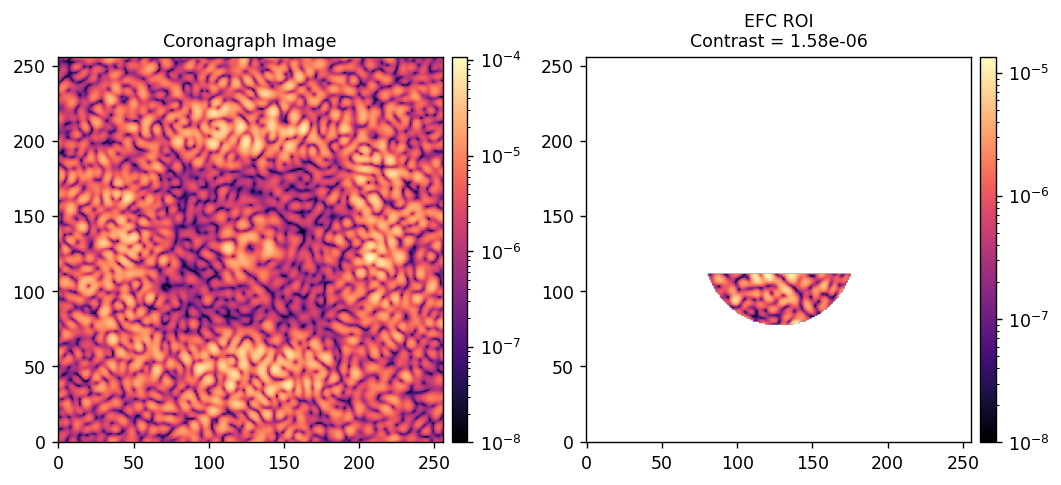

In [12]:
reload(iefc)
set_dm_fun(xp.zeros_like(dm_mask), **set_dm_params)
coro_im = take_im_fun(**take_im_params)
contrast = utils.mean(coro_im, wfs_mask)

utils.imshow(
    [coro_im, coro_im * wfs_mask],
    norms=[LogNorm(1e-8), LogNorm(1e-8)],
    titles=['Coronagraph Image', f'EFC ROI\nContrast = {contrast:.2e}'],
)

iefc_data = iefc.init_data()



[before iEFC run] xp=cupy, lina_cpp_device=gpu
[before iEFC run] control_model_device=gpu
Running iteration 307 / 309
	Measuring response of probe 1/2.
	Measuring response of probe 2/2.
Measuring dark hole state ...
	Ratio of pixels greater than zero versus total pixels: 2394 / 2394 = 1.00


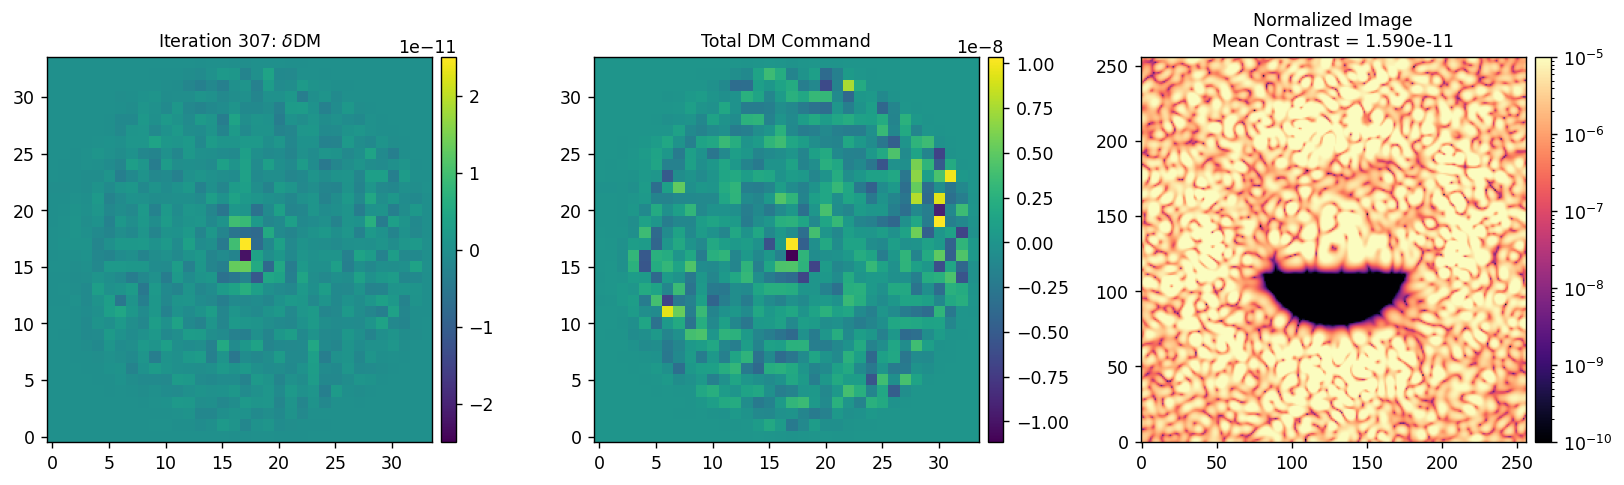

Running iteration 308 / 309
	Measuring response of probe 1/2.
	Measuring response of probe 2/2.
Measuring dark hole state ...
	Ratio of pixels greater than zero versus total pixels: 2394 / 2394 = 1.00


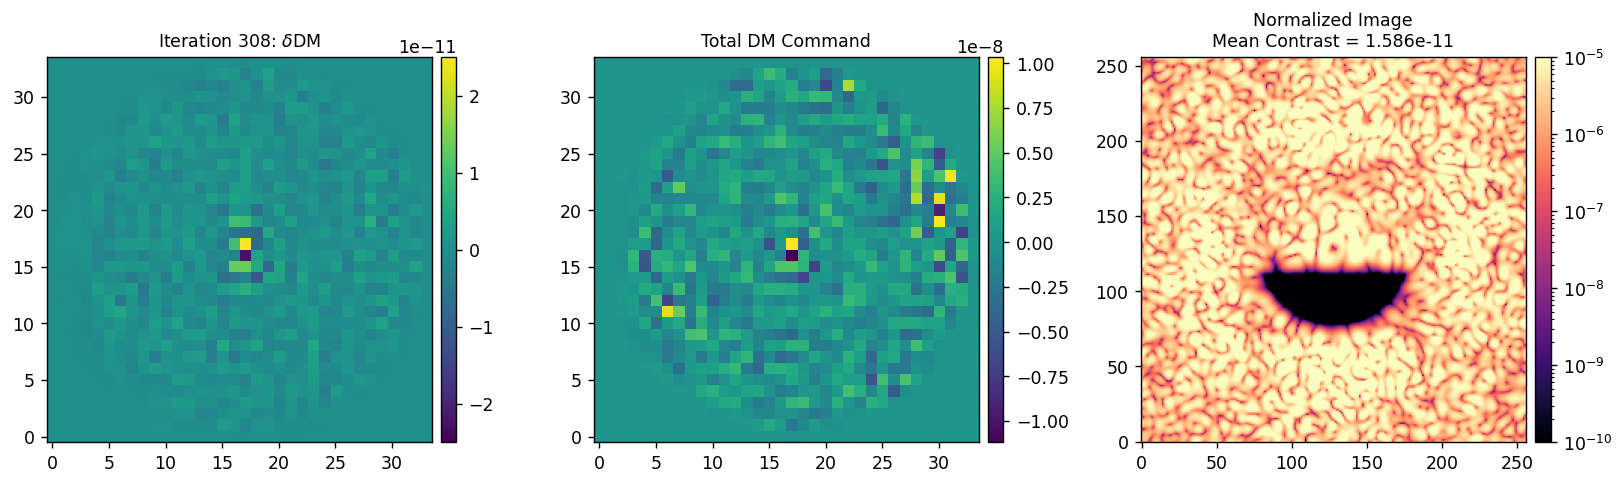

Running iteration 309 / 309
	Measuring response of probe 1/2.
	Measuring response of probe 2/2.
Measuring dark hole state ...
	Ratio of pixels greater than zero versus total pixels: 2394 / 2394 = 1.00


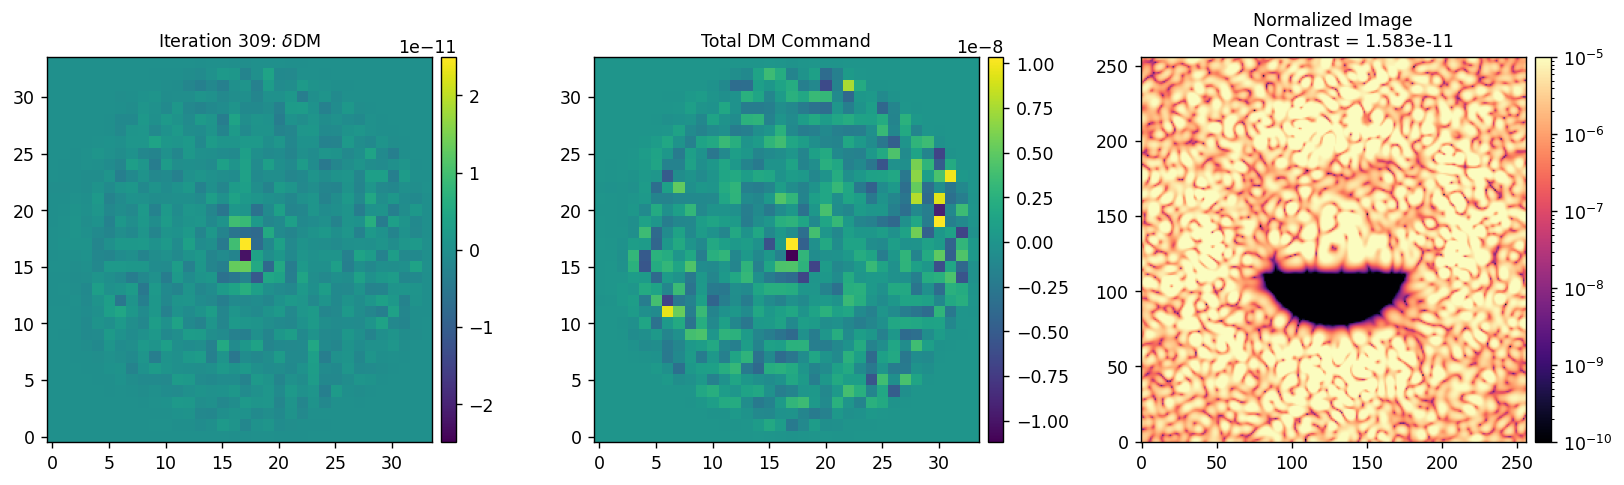

Completed 3 iterations in 1.241s.
iefc_run_elapsed_s=1.241


In [48]:
reload(utils)
reload(iefc)
report_cpp_backend('before iEFC run', C)

probe_amp = 2.5e-9
probe_amp = 1e-9
# probe_amp = 0.5e-9
# probe_amp = 0.25e-9
# probe_amp = 0.1e-9

t_run_start = time.perf_counter()
data = iefc.run(
    iefc_data,
    take_im_fun,
    take_im_params,
    set_dm_fun,
    set_dm_params,
    response_matrix,   # raw response matrix; run() applies beta_reg(reg_cond) internally
    -2.5,              # reg_cond (reproduces cm25 = beta_reg(response_matrix, -2.5))
    probe_modes,
    probe_amp,
    calib_modes,
    wfs_mask,
    num_iterations=3,
    gain=1.0,
    leakage=0.0,
    # normalize_diff_fun=None,
    # normalize_diff_params=None,
    # normalize_metric_fun=None,
    # normalize_metric_params=None,
    # plot_current=True,
    plot_all=True,
    vmin=1e-10,
)
print(f'iefc_run_elapsed_s={time.perf_counter() - t_run_start:.3f}')